# Notebook 09: Differential Privacy (DP-SGD & Opacus) in Federated Learning

## Objective
Implement **Differential Privacy (DP-SGD)** using PyTorch Opacus to protect local client model updates.

### Differential Privacy Mechanics
1. **Per-Sample Gradient Clipping**: Gradients are clipped to norm $C$ (`max_grad_norm`).
2. **Noise Addition**: Gaussian noise scaled by noise multiplier $\sigma$ is added to clipped gradients.
3. **Privacy Budget Tracking**: Opacus computes cumulative $(\epsilon, \delta)$-Differential Privacy expenditure.



In [2]:
import os
import sys
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath('..'))
from backend.ml.model import DiabetesRiskModel
from backend.privacy.differential_privacy import DPTrainerWrapper

# Load data
ha = pd.read_csv("../data/hospitals/hospital_A.csv")
hb = pd.read_csv("../data/hospitals/hospital_B.csv")
hc = pd.read_csv("../data/hospitals/hospital_C.csv")

feature_cols = ['age', 'systolic_bp', 'diastolic_bp', 'heart_rate', 'bmi', 'glucose', 'hba1c', 'cholesterol', 'creatinine']
target_col = 'diabetes'

scaler = StandardScaler()
all_df = pd.concat([ha, hb, hc])
scaler.fit(all_df[feature_cols])

X_global = scaler.transform(all_df[feature_cols].values)
y_global = all_df[target_col].values

ds = TensorDataset(torch.tensor(X_global, dtype=torch.float32), torch.tensor(y_global, dtype=torch.float32))
loader = DataLoader(ds, batch_size=32, shuffle=True)
print("Data loaded for DP-SGD experiments.")


Data loaded for DP-SGD experiments.


C:\Users\bahad\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


## 1. Privacy-Utility Tradeoff Experiment across Epsilon Budgets


In [3]:
epsilons = [0.5, 1.0, 2.0, 5.0, 10.0]
results = []

for eps in epsilons:
    model = DiabetesRiskModel(input_dim=len(feature_cols))
    optimizer = optim.Adam(model.parameters(), lr=0.01)
    
    # Calculate noise multiplier corresponding to target epsilon
    noise_mult = 1.0 / (eps + 1e-5)
    dp_wrapper = DPTrainerWrapper(epsilon=eps, delta=1e-5, max_grad_norm=1.0, noise_multiplier=noise_mult)
    
    dp_model, dp_opt, dp_loader, privacy_engine = dp_wrapper.attach(model, optimizer, loader)
    criterion = nn.BCEWithLogitsLoss()
    
    # Train model
    dp_model.train()
    for epoch in range(10):
        for bx, by in dp_loader:
            dp_opt.zero_grad()
            out = dp_model(bx).squeeze()
            loss = criterion(out, by)
            loss.backward()
            dp_opt.step()
            
    # Evaluate
    dp_model.eval()
    with torch.no_grad():
        logits = dp_model(torch.tensor(X_global, dtype=torch.float32)).squeeze()
        probs = torch.sigmoid(logits).numpy()
        preds = (probs >= 0.5).astype(float)
        
    acc = accuracy_score(y_global, preds)
    f1 = f1_score(y_global, preds, zero_division=0)
    results.append({'epsilon': eps, 'accuracy': acc, 'f1_score': f1})
    
    print(f"Target Epsilon: {eps:<5} -> Test Accuracy: {acc:.4f}, F1: {f1:.4f}")


Target Epsilon: 0.5   -> Test Accuracy: 0.9443, F1: 0.9528


Target Epsilon: 1.0   -> Test Accuracy: 0.9459, F1: 0.9538


Target Epsilon: 2.0   -> Test Accuracy: 0.9485, F1: 0.9561


Target Epsilon: 5.0   -> Test Accuracy: 0.9457, F1: 0.9540


KeyboardInterrupt: 

## 2. Plot Privacy vs. Utility Curve


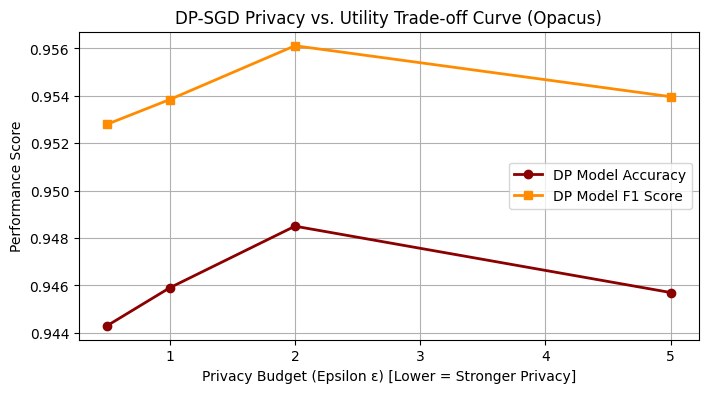

In [4]:
df_dp = pd.DataFrame(results)

plt.figure(figsize=(8, 4))
plt.plot(df_dp['epsilon'], df_dp['accuracy'], marker='o', linewidth=2, color='darkred', label='DP Model Accuracy')
plt.plot(df_dp['epsilon'], df_dp['f1_score'], marker='s', linewidth=2, color='darkorange', label='DP Model F1 Score')
plt.title("DP-SGD Privacy vs. Utility Trade-off Curve (Opacus)")
plt.xlabel("Privacy Budget (Epsilon ε) [Lower = Stronger Privacy]")
plt.ylabel("Performance Score")
plt.legend()
plt.grid(True)
plt.show()
